# CICIDS2017 Multi-Class Classification

In [1]:
import pandas as pd
import numpy as np
import glob
import os
import time
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from lightgbm import LGBMClassifier
import xgboost as xgb
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score

import warnings
warnings.filterwarnings('ignore')

## 1. Data Loading & Cleaning

In [2]:
files = glob.glob(r'../Datasets/CICIDS/*.csv')
print(f"Found {len(files)} CSV files.")

df_list = []
for f in files:
    sub_df = pd.read_csv(f)
    df_list.append(sub_df)

df = pd.concat(df_list, ignore_index=True)
df.columns = df.columns.str.strip()
df['Label'] = df['Label'].astype(str).str.strip().str.encode('ascii', 'ignore').str.decode('utf-8')
df['Label'] = df['Label'].replace('', 'UNKNOWN')

# Drop non-predictive identifier columns AND Destination Port to prevent leakage
drop_cols = ['Flow ID', 'Source IP', 'Source Port', 'Destination IP', 'Timestamp', 'Destination Port']
df = df.drop(columns=[c for c in drop_cols if c in df.columns])

# Clean Inf/NaNs
df = df.replace([np.inf, -np.inf], np.nan).dropna()

print("Processed Dataset Shape:", df.shape)
print("\nTarget Class Distribution:\n", df['Label'].value_counts())

Found 8 CSV files.
Processed Dataset Shape: (2827876, 78)

Target Class Distribution:
 Label
BENIGN                       2271320
DoS Hulk                      230124
PortScan                      158804
DDoS                          128025
DoS GoldenEye                  10293
FTP-Patator                     7935
SSH-Patator                     5897
DoS slowloris                   5796
DoS Slowhttptest                5499
Bot                             1956
Web Attack  Brute Force         1507
Web Attack  XSS                  652
Infiltration                      36
Web Attack  Sql Injection         21
Heartbleed                        11
Name: count, dtype: int64


## 2. Preprocessing & Train-Test Split

In [3]:
X = df.drop(columns=['Label'])
y = df['Label']

# Label Encode Target
target_encoder = LabelEncoder()
y_enc = target_encoder.fit_transform(y)

# Stratified Split (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y_enc, test_size=0.2, stratify=y_enc, random_state=42)

# Scale Numerical Features
num_cols = X_train.select_dtypes(exclude=['object', 'category']).columns.tolist()
scaler = StandardScaler()
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

print("Train shape:", X_train.shape, "Test shape:", X_test.shape)

Train shape: (2262300, 77) Test shape: (565576, 77)


## 3. Model Training & Comparison

In [4]:
models = {
    "LightGBM": LGBMClassifier(n_estimators=100, random_state=42, n_jobs=-1, verbose=-1),
    "XGBoost (Hist)": xgb.XGBClassifier(n_estimators=100, random_state=42, n_jobs=-1, tree_method='hist', objective='multi:softmax', num_class=len(target_encoder.classes_)),
    "HistGradientBoosting": HistGradientBoostingClassifier(max_iter=100, random_state=42),
    "Random Forest (Subsampled)": RandomForestClassifier(n_estimators=50, max_samples=0.2, random_state=42, n_jobs=-1)
}

results = []
for name, model in models.items():
    print(f"Training {name}...")
    start = time.time()
    model.fit(X_train, y_train)
    elapsed = time.time() - start
    
    preds = model.predict(X_test)
    acc = accuracy_score(y_test, preds)
    prec = precision_score(y_test, preds, average='weighted', zero_division=0)
    rec = recall_score(y_test, preds, average='weighted', zero_division=0)
    w_f1 = f1_score(y_test, preds, average='weighted', zero_division=0)
    m_f1 = f1_score(y_test, preds, average='macro', zero_division=0)
    
    results.append({
        'Model': name,
        'Accuracy': acc,
        'Weighted Precision': prec,
        'Weighted Recall': rec,
        'Weighted F1': w_f1,
        'Macro F1': m_f1,
        'Time (s)': elapsed
    })
    print(f"{name} - Acc: {acc:.4f}, Weighted F1: {w_f1:.4f}, Macro F1: {m_f1:.4f}")

results_df = pd.DataFrame(results)
display(results_df)

Training LightGBM...
LightGBM - Acc: 0.9659, Weighted F1: 0.9648, Macro F1: 0.3436
Training XGBoost (Hist)...
XGBoost (Hist) - Acc: 0.8808, Weighted F1: 0.8936, Macro F1: 0.2617
Training HistGradientBoosting...
HistGradientBoosting - Acc: 0.9891, Weighted F1: 0.9928, Macro F1: 0.6834
Training Random Forest (Subsampled)...
Random Forest (Subsampled) - Acc: 0.9982, Weighted F1: 0.9981, Macro F1: 0.8003


,Model,Accuracy,Weighted Precision,Weighted Recall,Weighted F1,Macro F1,Time (s)
0,LightGBM,0.965875,0.963780,0.965875,0.964805,0.343618,106.131793
1,XGBoost (Hist),0.880764,0.918781,0.880764,0.893556,0.261677,176.035107
2,HistGradientBoosting,0.989108,0.996607,0.989108,0.992797,0.683399,39.647399
3,Random Forest (Subsampled),0.998234,0.998146,0.998234,0.998132,0.800260,24.672769


## 4. Visualizing Results

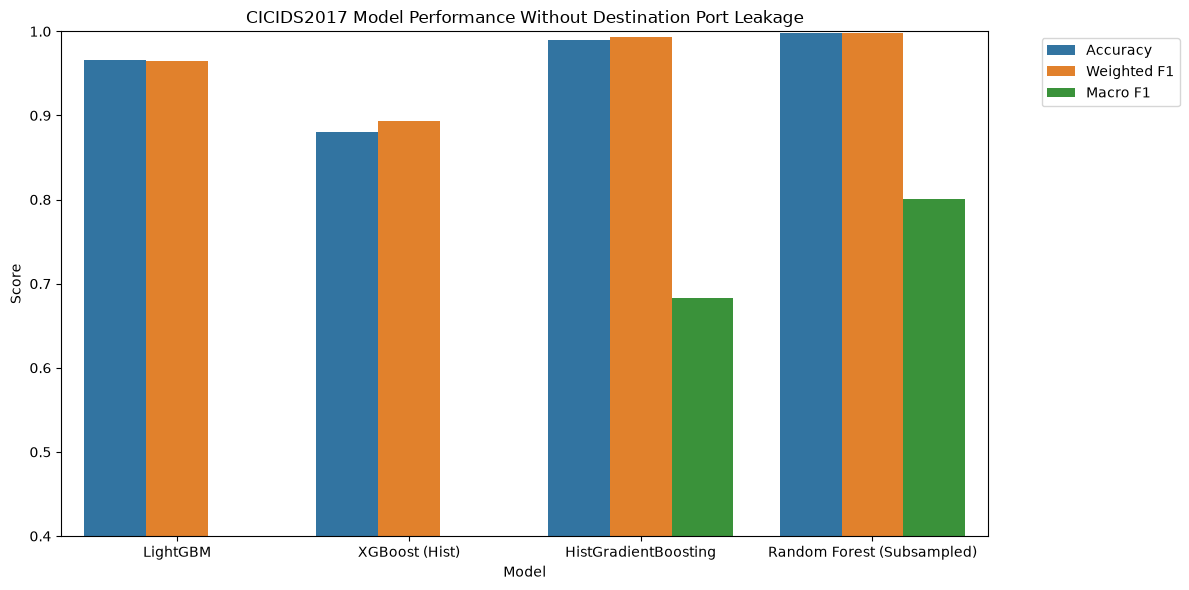

In [5]:
plt.figure(figsize=(12, 6))
melted_df = results_df.melt(id_vars='Model', value_vars=['Accuracy', 'Weighted F1', 'Macro F1'], var_name='Metric', value_name='Score')
sns.barplot(data=melted_df, x='Model', y='Score', hue='Metric')
plt.title('CICIDS2017 Model Performance Without Destination Port Leakage')
plt.ylim(0.4, 1.0)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()